# 71 - Parity Ladder: MATLAB UltraTimTrack vs Python Framework

This notebook builds a frame-by-frame parity ladder for `UltraTimTrack_test.mp4`. It compares MATLAB and Python at the earliest saved rungs available in `data/matlab/slow_low_01_DOWN_tracked_Q=001.mat`, then walks downstream to the final `FL/PEN/ANG` outputs.

The purpose is not only to ask whether final outputs are close, but to locate the first available stage where the two independent implementations diverge.

Available MATLAB rungs in this `.mat` file:

- final aliases: `Fdat.Region.FL/PEN/ANG` and `fas_length/fas_pen/fas_ang`;
- TimTrack saved geofeatures: `alpha`, `super_pos`, `deep_pos`, `betha`, `gamma`, `thickness`, `faslen`;
- Region/aponeurosis traces: `sup_x/sup_y`, `deep_x/deep_y`;
- fascicle/Kalman traces: `Fascicle.fas_x_original`, `fas_y_original`, `fas_x`, `fas_y`, `fas_x_end`, `fas_y_end`, `X_plus`, `X_minus`.

If the first mismatch is already present at the TimTrack/geofeature rung, exact parity requires extra MATLAB exports below this file's save boundary: raw filtered images, binary masks, Hough accumulators/peaks, KLT points, and numeric affine transforms.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

sys.dont_write_bytecode = True

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
PYTHON_NPZ = ROOT / 'results' / 'notebook70_matlab_normal_adaptive_kalman_comparison' / 'python_adaptive_with_fixed_reference' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
PYTHON_META = ROOT / 'results' / 'notebook70_matlab_normal_adaptive_kalman_comparison' / 'python_adaptive_with_fixed_reference' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_metadata.json'
OUT = ROOT / 'results' / 'notebook71_parity_ladder_matlab_vs_python'
OUT.mkdir(parents=True, exist_ok=True)

for required in [VIDEO, MATLAB_RESULT, PYTHON_NPZ, PYTHON_META]:
    assert required.exists(), required

cap = cv2.VideoCapture(str(VIDEO))
assert cap.isOpened(), VIDEO
fps = float(cap.get(cv2.CAP_PROP_FPS))
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

mat = loadmat(MATLAB_RESULT, simplify_cells=True)
tracking = mat['TrackingData']
fdat = mat['Fdat']
region = fdat['Region']
geofeatures = list(fdat['geofeatures'])
fascicle = region['Fascicle']

with np.load(PYTHON_NPZ, allow_pickle=True) as data:
    py = {key: data[key] for key in data.files}
py_meta = json.loads(PYTHON_META.read_text())

print('video frames:', n_video_frames, 'fps:', fps, 'size:', (frame_width, frame_height))
print('MATLAB rows:', len(geofeatures), 'TrackingData.NumFrames:', tracking.get('NumFrames'))
print('Python frames:', len(py['frame']))
print('OUT:', OUT)

video frames: 2667 fps: 33.341 size: (706, 562)
MATLAB rows: 2666 TrackingData.NumFrames: 2666
Python frames: 2667
OUT: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python


## 2. Helper Functions and Alignment

In [2]:
def as_float1(values) -> np.ndarray:
    return np.asarray(values, dtype=float).reshape(-1)


def object_series_to_2d(values, width: int | None = None) -> np.ndarray:
    arr = np.asarray(values, dtype=object).reshape(-1)
    if width is None:
        width = max(len(np.asarray(v).reshape(-1)) for v in arr if np.asarray(v).size)
    out = np.full((len(arr), width), np.nan, dtype=float)
    for idx, value in enumerate(arr):
        flat = np.asarray(value, dtype=float).reshape(-1)
        n = min(width, len(flat))
        if n:
            out[idx, :n] = flat[:n]
    return out


def matlab_fascicle_segment(x_values, y_values) -> np.ndarray:
    xs = np.asarray(x_values, dtype=object).reshape(-1)
    ys = np.asarray(y_values, dtype=object).reshape(-1)
    out = np.full((len(xs), 4), np.nan, dtype=float)
    for idx, (xv, yv) in enumerate(zip(xs, ys)):
        x = np.asarray(xv, dtype=float).reshape(-1)
        y = np.asarray(yv, dtype=float).reshape(-1)
        if len(x) < 2 or len(y) < 2:
            continue
        sup_idx = int(np.nanargmin(y[:2]))
        deep_idx = 1 - sup_idx
        out[idx] = [x[sup_idx], y[sup_idx], x[deep_idx], y[deep_idx]]
    return out


def line_angle_deg_from_y(y1, y2, *, x1: float = 1.0, x2: float | None = None) -> np.ndarray:
    if x2 is None:
        x2 = float(frame_width)
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)
    return np.rad2deg(np.arctan2(-(y2 - y1), x2 - x1))


def segment_angle_deg(segments: np.ndarray) -> np.ndarray:
    seg = np.asarray(segments, dtype=float)
    return np.rad2deg(np.arctan2(-(seg[:, 3] - seg[:, 1]), seg[:, 2] - seg[:, 0]))


def segment_length_px(segments: np.ndarray) -> np.ndarray:
    seg = np.asarray(segments, dtype=float)
    return np.hypot(seg[:, 2] - seg[:, 0], seg[:, 3] - seg[:, 1])


def line_y_at_x_from_y_endpoints(y1, y2, x_eval: float, *, x1: float = 1.0, x2: float | None = None) -> np.ndarray:
    if x2 is None:
        x2 = float(frame_width)
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)
    return y1 + (y2 - y1) * ((float(x_eval) - x1) / (x2 - x1))


def thickness_from_endpoints(super_y1, super_y2, deep_y1, deep_y2, *, x_eval: float = 20.0) -> np.ndarray:
    beta = line_angle_deg_from_y(super_y1, super_y2)
    super_y = line_y_at_x_from_y_endpoints(super_y1, super_y2, x_eval)
    deep_y = line_y_at_x_from_y_endpoints(deep_y1, deep_y2, x_eval)
    return (deep_y - super_y) * np.cos(np.deg2rad(beta))


def metrics(reference, estimate) -> dict[str, float | int]:
    ref = np.asarray(reference, dtype=float).reshape(-1)
    est = np.asarray(estimate, dtype=float).reshape(-1)
    n = min(len(ref), len(est))
    ref = ref[:n]
    est = est[:n]
    mask = np.isfinite(ref) & np.isfinite(est)
    ref = ref[mask]
    est = est[mask]
    if len(ref) == 0:
        return {'n': 0, 'bias': np.nan, 'mae': np.nan, 'rmse': np.nan, 'max_abs': np.nan, 'corr': np.nan}
    diff = est - ref
    corr = float(np.corrcoef(ref, est)[0, 1]) if len(ref) > 1 and np.std(ref) > 0 and np.std(est) > 0 else np.nan
    return {
        'n': int(len(diff)),
        'bias': float(np.mean(diff)),
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff * diff))),
        'max_abs': float(np.max(np.abs(diff))),
        'corr': corr,
    }


def add_metric(rows, rung_index: int, rung: str, variable: str, unit: str, reference, estimate, tolerance: float, ref_source: str, py_source: str):
    row = {
        'rung_index': rung_index,
        'rung': rung,
        'variable': variable,
        'unit': unit,
        'diagnostic_tolerance': float(tolerance),
        'reference_source': ref_source,
        'python_source': py_source,
    }
    row.update(metrics(reference, estimate))
    row['within_tolerance'] = bool(np.isfinite(row['rmse']) and row['rmse'] <= tolerance)
    rows.append(row)


mat_time = as_float1(region['Time'])
py_time = as_float1(py['time_s'])
offset_scores = []
for offset in range(0, min(5, len(py_time))):
    n = min(len(mat_time), len(py_time) - offset)
    if n <= 0:
        continue
    sample = min(n, 250)
    offset_scores.append({
        'python_offset': offset,
        'n_overlap': n,
        'median_abs_time_error_s_first250': float(np.nanmedian(np.abs(py_time[offset:offset + sample] - mat_time[:sample]))),
    })
offset_table = pd.DataFrame(offset_scores)
PY_OFFSET = int(offset_table.sort_values('median_abs_time_error_s_first250').iloc[0]['python_offset'])
N = int(min(len(mat_time), len(py_time) - PY_OFFSET))
SL = slice(PY_OFFSET, PY_OFFSET + N)

print('Selected Python offset:', PY_OFFSET)
display(offset_table)

Selected Python offset: 1


,python_offset,n_overlap,median_abs_time_error_s_first250
0,0,2666,0.029992
1,1,2666,0.000001
2,2,2665,0.029994
3,3,2664,0.059987
4,4,2663,0.089981


## 3. Build MATLAB and Python Rung Arrays

In [3]:
# MATLAB TimTrack/geofeature arrays.
mat_geo = pd.DataFrame({
    'alpha_deg': [float(np.asarray(e['alpha']).reshape(-1)[0]) for e in geofeatures],
    'betha_super_deg': [float(np.asarray(e['betha']).reshape(-1)[0]) for e in geofeatures],
    'gamma_deep_deg': [float(np.asarray(e['gamma']).reshape(-1)[0]) for e in geofeatures],
    'thickness_px': [float(np.asarray(e['thickness']).reshape(-1)[0]) for e in geofeatures],
    'faslen_px': [float(np.asarray(e['faslen']).reshape(-1)[0]) for e in geofeatures],
    'phi_deg': [float(np.asarray(e['phi']).reshape(-1)[0]) for e in geofeatures],
    'super_y1': [float(np.asarray(e['super_pos'], dtype=float).reshape(-1)[0]) for e in geofeatures],
    'super_y2': [float(np.asarray(e['super_pos'], dtype=float).reshape(-1)[1]) for e in geofeatures],
    'deep_y1': [float(np.asarray(e['deep_pos'], dtype=float).reshape(-1)[0]) for e in geofeatures],
    'deep_y2': [float(np.asarray(e['deep_pos'], dtype=float).reshape(-1)[1]) for e in geofeatures],
})

# MATLAB Region/final arrays.
mat_region_sup_y = object_series_to_2d(region['sup_y'], 2)
mat_region_deep_y = object_series_to_2d(region['deep_y'], 2)
mat_final = pd.DataFrame({
    'FL_mm': as_float1(region['FL']),
    'PEN_deg': as_float1(region['PEN']),
    'ANG_deg': as_float1(region['ANG']),
    'fas_length_mm': as_float1(region['fas_length']),
    'fas_pen_deg': as_float1(region['fas_pen']),
    'fas_ang_deg': as_float1(region['fas_ang']),
    'sup_y1': mat_region_sup_y[:, 0],
    'sup_y2': mat_region_sup_y[:, 1],
    'deep_y1': mat_region_deep_y[:, 0],
    'deep_y2': mat_region_deep_y[:, 1],
})
mat_final['super_angle_deg'] = line_angle_deg_from_y(mat_final['sup_y1'], mat_final['sup_y2'])
mat_final['deep_angle_deg'] = line_angle_deg_from_y(mat_final['deep_y1'], mat_final['deep_y2'])

# MATLAB fascicle/Kalman arrays.
mat_fas_original = matlab_fascicle_segment(fascicle['fas_x_original'], fascicle['fas_y_original'])
mat_fas_state = matlab_fascicle_segment(fascicle['fas_x'], fascicle['fas_y'])
mat_fas_end = matlab_fascicle_segment(fascicle['fas_x_end'], fascicle['fas_y_end'])
mat_x_plus = object_series_to_2d(fascicle['X_plus'], 2)
mat_x_minus = object_series_to_2d(fascicle['X_minus'], 2)

# Python arrays aligned to MATLAB rows. Use fixed/normal Kalman as parity target.
py_fixed_ang = as_float1(py.get('fixed_ANG_deg', py['ANG_deg']))[SL]
py_fixed_pen = as_float1(py.get('fixed_PEN_deg', py['PEN_deg']))[SL]
py_fixed_fl = as_float1(py.get('fixed_FL_mm', py['FL_mm']))[SL]
py_fixed_segments = np.asarray(py.get('fixed_fascicle_segments', py['fascicle_segments']), dtype=float)[SL]
py_fixed_end_segments = np.asarray(py.get('fixed_fascicle_end_segments', py['fascicle_end_segments']), dtype=float)[SL]

py_apo_meas = np.asarray(py['apo_measurement_states'], dtype=float)[SL]
py_apo_filtered_sup = np.asarray(py['sup_apo_lines'], dtype=float)[SL]
py_apo_filtered_deep = np.asarray(py['deep_apo_lines'], dtype=float)[SL]
py_klt_prior = np.asarray(py['klt_prior_segments'], dtype=float)[SL]

# Shape checks.
assert len(mat_geo) == N
assert len(mat_final) == N
assert len(py_fixed_ang) == N

print('Built arrays for', N, 'matched MATLAB/Python rows.')

Built arrays for 2666 matched MATLAB/Python rows.


## 4. Ladder Metrics

In [4]:
rows = []

# Rung 0: MATLAB final aliases are exactly the same variable content.
add_metric(rows, 0, 'MATLAB variable alias check', 'FL vs fas_length', 'mm', mat_final['FL_mm'], mat_final['fas_length_mm'], 1e-10, 'Fdat.Region.FL', 'Fdat.Region.fas_length')
add_metric(rows, 0, 'MATLAB variable alias check', 'PEN vs fas_pen', 'deg', mat_final['PEN_deg'], mat_final['fas_pen_deg'], 1e-10, 'Fdat.Region.PEN', 'Fdat.Region.fas_pen')
add_metric(rows, 0, 'MATLAB variable alias check', 'ANG vs fas_ang', 'deg', mat_final['ANG_deg'], mat_final['fas_ang_deg'], 1e-10, 'Fdat.Region.ANG', 'Fdat.Region.fas_ang')

# Rung 1: frame/time alignment.
add_metric(rows, 1, 'Frame/time alignment', 'time', 's', mat_time[:N], py_time[SL], 5e-5, 'Fdat.Region.Time', 'Python time_s')

# Rung 2: saved TimTrack/geofeature measurements vs Python image-derived measurements.
add_metric(rows, 2, 'TimTrack geofeature measurement', 'fascicle alpha raw', 'deg', mat_geo['alpha_deg'], py['raw_timtrack_alpha_deg'][SL], 0.25, 'Fdat.geofeatures.alpha', 'Python raw_timtrack_alpha_deg')
add_metric(rows, 2, 'TimTrack geofeature measurement', 'fascicle alpha selected', 'deg', mat_geo['alpha_deg'], py['timtrack_alpha_deg'][SL], 0.25, 'Fdat.geofeatures.alpha', 'Python timtrack_alpha_deg')
for idx, label in enumerate(['super_y1', 'super_y2', 'deep_y1', 'deep_y2']):
    add_metric(rows, 2, 'TimTrack geofeature measurement', label, 'px', mat_geo[label], py_apo_meas[:, idx], 0.5, f'Fdat.geofeatures.{label}', f'Python apo_measurement_states[:, {idx}]')
add_metric(rows, 2, 'TimTrack geofeature measurement', 'super angle betha', 'deg', mat_geo['betha_super_deg'], line_angle_deg_from_y(py_apo_meas[:, 0], py_apo_meas[:, 1]), 0.25, 'Fdat.geofeatures.betha', 'angle(Python apo_measurement_states super)')
add_metric(rows, 2, 'TimTrack geofeature measurement', 'deep angle gamma', 'deg', mat_geo['gamma_deep_deg'], line_angle_deg_from_y(py_apo_meas[:, 2], py_apo_meas[:, 3]), 0.25, 'Fdat.geofeatures.gamma', 'angle(Python apo_measurement_states deep)')
add_metric(rows, 2, 'TimTrack geofeature measurement', 'muscle thickness', 'px', mat_geo['thickness_px'], thickness_from_endpoints(py_apo_meas[:, 0], py_apo_meas[:, 1], py_apo_meas[:, 2], py_apo_meas[:, 3]), 1.0, 'Fdat.geofeatures.thickness', 'Python measurement-line thickness')

# Rung 3: aponeurosis state/filter output.
for mat_col, py_arr, label in [
    ('sup_y1', py_apo_filtered_sup[:, 1], 'super filtered y1'),
    ('sup_y2', py_apo_filtered_sup[:, 3], 'super filtered y2'),
    ('deep_y1', py_apo_filtered_deep[:, 1], 'deep filtered y1'),
    ('deep_y2', py_apo_filtered_deep[:, 3], 'deep filtered y2'),
]:
    add_metric(rows, 3, 'Aponeurosis state/filter output', label, 'px', mat_final[mat_col], py_arr, 0.5, f'Fdat.Region.{mat_col}', 'Python filtered apo lines')
add_metric(rows, 3, 'Aponeurosis state/filter output', 'super filtered angle', 'deg', mat_final['super_angle_deg'], segment_angle_deg(py_apo_filtered_sup), 0.25, 'angle(Fdat.Region.sup_y)', 'angle(Python sup_apo_lines)')
add_metric(rows, 3, 'Aponeurosis state/filter output', 'deep filtered angle', 'deg', mat_final['deep_angle_deg'], segment_angle_deg(py_apo_filtered_deep), 0.25, 'angle(Fdat.Region.deep_y)', 'angle(Python deep_apo_lines)')

# Rung 4: KLT/propagated fascicle prior against MATLAB original fascicle trace.
for col, label, unit, tol in [
    (0, 'KLT prior x_sup', 'px', 1.0),
    (1, 'KLT prior y_sup', 'px', 1.0),
    (2, 'KLT prior x_deep', 'px', 1.0),
    (3, 'KLT prior y_deep', 'px', 1.0),
]:
    add_metric(rows, 4, 'KLT / fascicle prior', label, unit, mat_fas_original[:, col], py_klt_prior[:, col], tol, 'MATLAB Fascicle.fas_x/y_original', 'Python klt_prior_segments')
add_metric(rows, 4, 'KLT / fascicle prior', 'KLT prior length', 'px', segment_length_px(mat_fas_original), segment_length_px(py_klt_prior), 2.0, 'length(MATLAB fas_original)', 'length(Python klt_prior_segments)')
add_metric(rows, 4, 'KLT / fascicle prior', 'KLT prior angle', 'deg', segment_angle_deg(mat_fas_original), segment_angle_deg(py_klt_prior), 0.25, 'angle(MATLAB fas_original)', 'angle(Python klt_prior_segments)')

# Rung 5: final Kalman state/fascicle geometry.
# MATLAB X_plus is the forward-filter state; the cached Python NPZ only saves
# smoothed fixed-R geometry/outputs. Do not compare forward X_plus with those
# smoothed arrays. See docs/notebook71_rungs4_5_math_audit.md for the corrected
# forward-vs-forward and smoothed-vs-smoothed state audit.
for col, label in enumerate(['final x_sup', 'final y_sup', 'final x_deep', 'final y_deep']):
    add_metric(rows, 5, 'Fascicle Kalman state/output geometry', label, 'px', mat_fas_state[:, col], py_fixed_segments[:, col], 1.0, 'MATLAB Fascicle.fas_x/fas_y', 'Python fixed_fascicle_segments')
for col, label in enumerate(['final-end x_sup', 'final-end y_sup', 'final-end x_deep', 'final-end y_deep']):
    add_metric(rows, 5, 'Fascicle Kalman state/output geometry', label, 'px', mat_fas_end[:, col], py_fixed_end_segments[:, col], 1.0, 'MATLAB Fascicle.fas_x_end/fas_y_end', 'Python fixed_fascicle_end_segments')
add_metric(rows, 5, 'Fascicle Kalman state/output geometry', 'final-end length', 'px', segment_length_px(mat_fas_end), segment_length_px(py_fixed_end_segments), 2.0, 'length(MATLAB fas_end)', 'length(Python fixed_end_segments)')

# Rung 6: final output variables.
add_metric(rows, 6, 'Final output variables', 'FL', 'mm', mat_final['FL_mm'], py_fixed_fl, 0.5, 'Fdat.Region.FL/fas_length', 'Python fixed_FL_mm')
add_metric(rows, 6, 'Final output variables', 'PEN', 'deg', mat_final['PEN_deg'], py_fixed_pen, 0.5, 'Fdat.Region.PEN/fas_pen', 'Python fixed_PEN_deg')
add_metric(rows, 6, 'Final output variables', 'ANG', 'deg', mat_final['ANG_deg'], py_fixed_ang, 0.5, 'Fdat.Region.ANG/fas_ang', 'Python fixed_ANG_deg')

ladder = pd.DataFrame(rows)
ladder_path = OUT / 'parity_ladder_metrics.csv'
ladder.to_csv(ladder_path, index=False)

rung_summary = (
    ladder.groupby(['rung_index', 'rung'], as_index=False)
    .agg(
        n_variables=('variable', 'count'),
        n_within_tolerance=('within_tolerance', 'sum'),
        max_rmse=('rmse', 'max'),
        median_rmse=('rmse', 'median'),
        max_abs_error=('max_abs', 'max'),
    )
)
rung_summary['all_within_tolerance'] = rung_summary['n_variables'] == rung_summary['n_within_tolerance']
rung_summary_path = OUT / 'parity_ladder_rung_summary.csv'
rung_summary.to_csv(rung_summary_path, index=False)

first_fail = rung_summary.loc[~rung_summary['all_within_tolerance']].sort_values('rung_index').head(1)
print('Saved:', ladder_path)
print('Saved:', rung_summary_path)
display(rung_summary)
ladder.sort_values(['rung_index', 'rmse'], ascending=[True, False]).head(20)

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python/parity_ladder_metrics.csv
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python/parity_ladder_rung_summary.csv


,rung_index,rung,n_variables,n_within_tolerance,max_rmse,median_rmse,max_abs_error,all_within_tolerance
0,0,MATLAB variable alias check,3,3,0.000000,0.000000,0.000000,True
1,1,Frame/time alignment,1,1,0.000015,0.000015,0.000026,True
2,2,TimTrack geofeature measurement,9,1,2.920088,1.804496,14.509857,False
3,3,Aponeurosis state/filter output,6,2,1.845593,0.910450,6.732464,False
4,4,KLT / fascicle prior,6,0,38.494962,9.909090,81.539304,False
5,5,Fascicle Kalman state/output geometry,9,0,52.449927,21.385711,97.735406,False
6,6,Final output variables,3,0,2.867034,1.599246,6.282391,False


,rung_index,rung,variable,unit,diagnostic_tolerance,reference_source,python_source,n,bias,mae,rmse,max_abs,corr,within_tolerance
0,0,MATLAB variable alias check,FL vs fas_length,mm,1.000000e-10,Fdat.Region.FL,Fdat.Region.fas_length,2666,0.000000,0.000000,0.000000,0.000000,1.000000,True
1,0,MATLAB variable alias check,PEN vs fas_pen,deg,1.000000e-10,Fdat.Region.PEN,Fdat.Region.fas_pen,2666,0.000000,0.000000,0.000000,0.000000,1.000000,True
2,0,MATLAB variable alias check,ANG vs fas_ang,deg,1.000000e-10,Fdat.Region.ANG,Fdat.Region.fas_ang,2666,0.000000,0.000000,0.000000,0.000000,1.000000,True
3,1,Frame/time alignment,time,s,5.000000e-05,Fdat.Region.Time,Python time_s,2666,0.000013,0.000013,0.000015,0.000026,1.000000,True
5,2,TimTrack geofeature measurement,fascicle alpha selected,deg,2.500000e-01,Fdat.geofeatures.alpha,Python timtrack_alpha_deg,2666,1.453301,1.628470,2.920088,14.500000,0.884961,False
4,2,TimTrack geofeature measurement,fascicle alpha raw,deg,2.500000e-01,Fdat.geofeatures.alpha,Python raw_timtrack_alpha_deg,2666,1.408477,1.618905,2.899349,14.500000,0.884851,False
6,2,TimTrack geofeature measurement,super_y1,px,5.000000e-01,Fdat.geofeatures.super_y1,"Python apo_measurement_states[:, 0]",2666,1.420848,1.951664,2.781271,14.509857,0.692269,False
12,2,TimTrack geofeature measurement,muscle thickness,px,1.000000e+00,Fdat.geofeatures.thickness,Python measurement-line thickness,2666,-0.852198,1.915013,2.607145,13.420311,0.909212,False
8,2,TimTrack geofeature measurement,deep_y1,px,5.000000e-01,Fdat.geofeatures.deep_y1,"Python apo_measurement_states[:, 2]",2666,0.799729,1.184342,1.804496,6.892672,0.957228,False
7,2,TimTrack geofeature measurement,super_y2,px,5.000000e-01,Fdat.geofeatures.super_y2,"Python apo_measurement_states[:, 1]",2666,1.014233,1.295319,1.731888,8.338919,0.797556,False


## 5. Diagnostic Plots

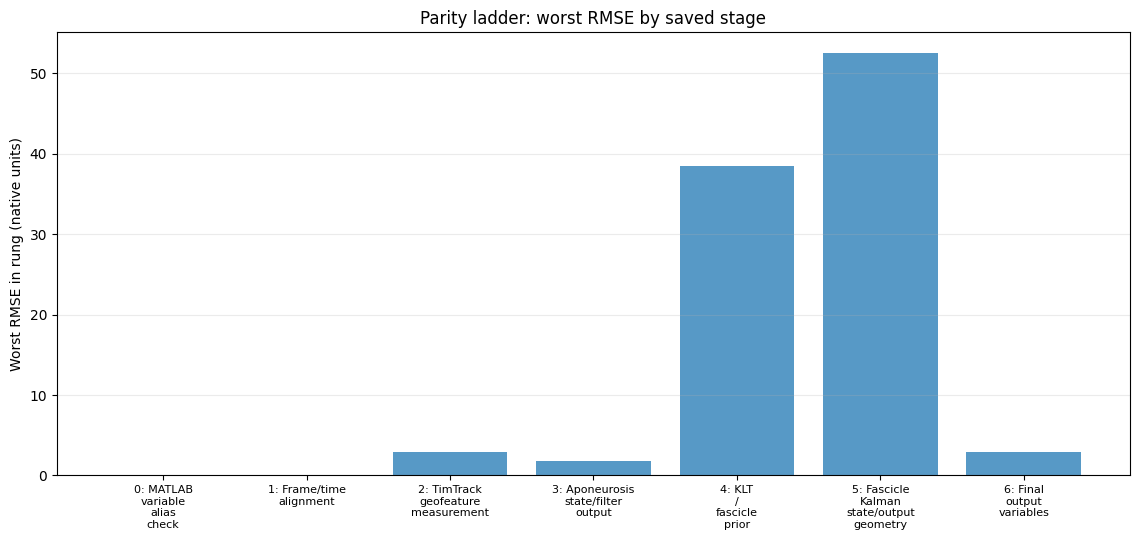

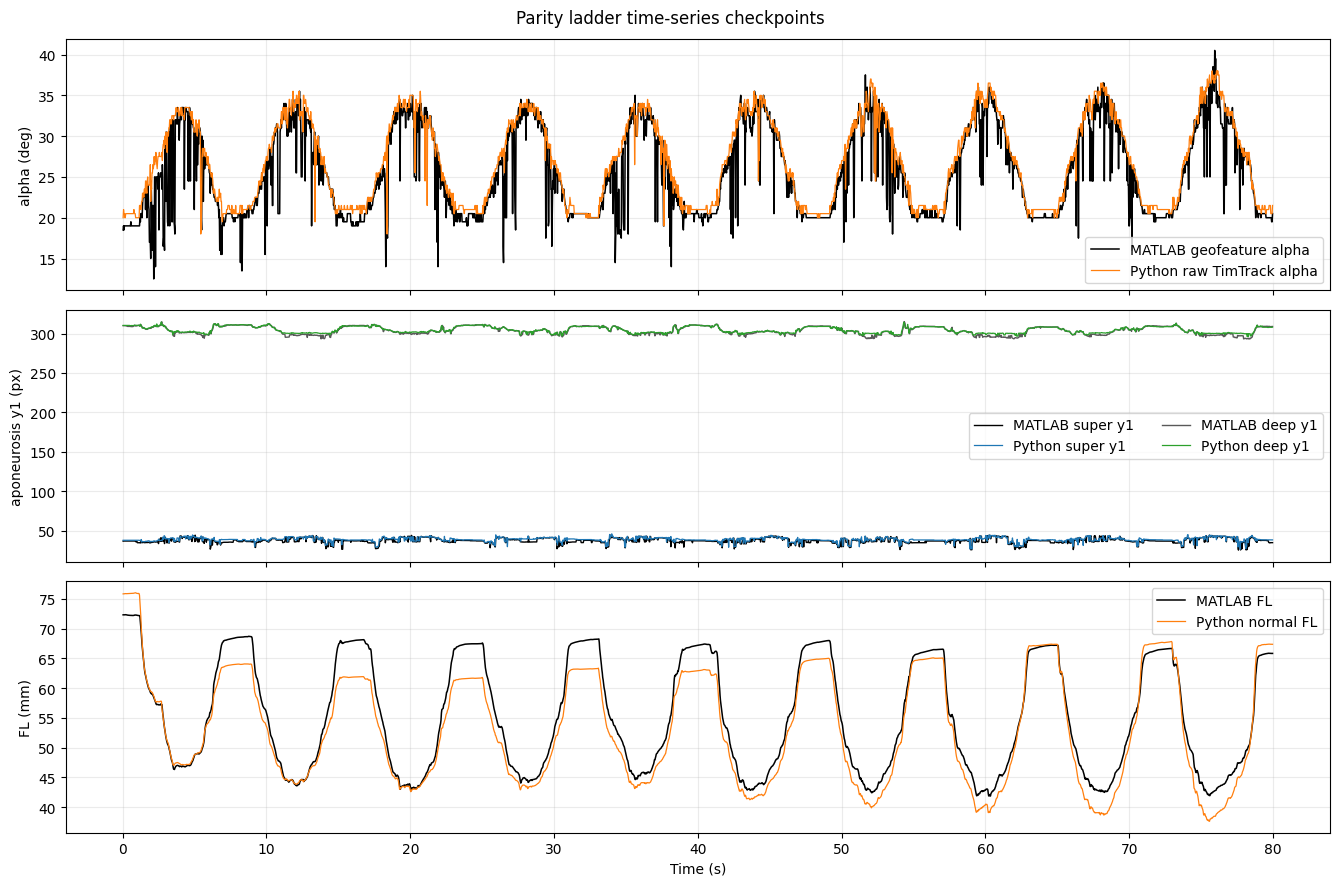

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python/parity_ladder_worst_rmse_by_rung.png
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python/parity_ladder_time_series_checkpoints.png


In [5]:
# Compact rung RMSE overview: one bar per rung using the worst RMSE in that rung.
fig, ax = plt.subplots(figsize=(11.5, 5.5))
plot_summary = rung_summary.copy()
ax.bar(plot_summary['rung_index'].astype(str) + ': ' + plot_summary['rung'].str.replace(' ', '\n'), plot_summary['max_rmse'], color='tab:blue', alpha=0.75)
ax.set_ylabel('Worst RMSE in rung (native units)')
ax.set_title('Parity ladder: worst RMSE by saved stage')
ax.grid(True, axis='y', alpha=0.25)
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_fontsize(8)
fig.tight_layout()
rung_plot = OUT / 'parity_ladder_worst_rmse_by_rung.png'
fig.savefig(rung_plot, dpi=180)
plt.show()

# Time-series checks for the first divergent saved rung and final outputs.
t = mat_time[:N]
fig, axes = plt.subplots(3, 1, figsize=(13.5, 9), sharex=True)
axes[0].plot(t, mat_geo['alpha_deg'], color='black', lw=1.1, label='MATLAB geofeature alpha')
axes[0].plot(t, py['raw_timtrack_alpha_deg'][SL], color='tab:orange', lw=0.9, label='Python raw TimTrack alpha')
axes[0].set_ylabel('alpha (deg)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.25)

axes[1].plot(t, mat_geo['super_y1'], color='black', lw=1.0, label='MATLAB super y1')
axes[1].plot(t, py_apo_meas[:, 0], color='tab:blue', lw=0.9, label='Python super y1')
axes[1].plot(t, mat_geo['deep_y1'], color='0.35', lw=1.0, label='MATLAB deep y1')
axes[1].plot(t, py_apo_meas[:, 2], color='tab:green', lw=0.9, label='Python deep y1')
axes[1].set_ylabel('aponeurosis y1 (px)')
axes[1].legend(loc='best', ncol=2)
axes[1].grid(True, alpha=0.25)

axes[2].plot(t, mat_final['FL_mm'], color='black', lw=1.1, label='MATLAB FL')
axes[2].plot(t, py_fixed_fl, color='tab:orange', lw=0.9, label='Python normal FL')
axes[2].set_ylabel('FL (mm)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.25)
fig.suptitle('Parity ladder time-series checkpoints')
fig.tight_layout()
checkpoint_plot = OUT / 'parity_ladder_time_series_checkpoints.png'
fig.savefig(checkpoint_plot, dpi=180)
plt.show()

print('Saved:', rung_plot)
print('Saved:', checkpoint_plot)

## 6. Interpretation and MATLAB Data Needed for Deeper Parity

In [6]:
if first_fail.empty:
    first_fail_text = 'All saved rungs were within the diagnostic tolerances.'
else:
    row = first_fail.iloc[0]
    first_fail_text = f"First saved rung outside tolerance: rung {int(row['rung_index'])}, {row['rung']}."

# The detailed failure rows for the first failing rung.
if first_fail.empty:
    first_fail_rows = pd.DataFrame()
else:
    first_idx = int(first_fail.iloc[0]['rung_index'])
    first_fail_rows = ladder[(ladder['rung_index'] == first_idx) & (~ladder['within_tolerance'])].copy()
    first_fail_rows = first_fail_rows.sort_values('rmse', ascending=False)
    first_fail_rows.to_csv(OUT / 'first_failing_rung_rows.csv', index=False)

needed_if_fixing = [
    'Per-frame MATLAB filtered ultrasound image after filter_usimage, before thresholding.',
    'Per-frame MATLAB fascicle/aponeurosis binary masks used for Hough detection.',
    'MATLAB Hough accumulator/Theta/Rho arrays and houghpeaks output before final alpha selection.',
    'MATLAB KLT feature point coordinates/status before and after tracking for fascicle and aponeurosis masks.',
    'Numeric affine matrices for MATLAB warp/awarp, exported as plain 3x3 matrices or affine parameters rather than MCOS objects.',
    'If Kalman parity is still suspect after upstream parity, per-frame numeric X_minus, X_plus, P, K, Q, and R values are useful; X_plus is already partly available here.',
]

summary_lines = [
    '# Notebook 71 parity ladder summary',
    '',
    f'Compared {N} matched MATLAB/Python rows from `{VIDEO.name}` using Python offset {PY_OFFSET}.',
    first_fail_text,
    '',
    'The current MATLAB `.mat` file is sufficient to locate the first available saved mismatch, but not sufficient to inspect every raw image-processing operation below that mismatch.',
    '',
    'Additional MATLAB exports needed only if we want to fix exact low-level parity:',
]
summary_lines.extend(f'- {item}' for item in needed_if_fixing)
summary_lines.extend([
    '',
    f'Ladder metrics CSV: `{ladder_path}`',
    f'Rung summary CSV: `{rung_summary_path}`',
    f'Rung RMSE plot: `{rung_plot}`',
    f'Time-series checkpoint plot: `{checkpoint_plot}`',
])
summary_text = '\n'.join(summary_lines)
summary_path = OUT / 'notebook71_parity_ladder_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')

print(summary_text)
display(first_fail_rows.head(20))
print('\nSaved:', summary_path)

# Notebook 71 parity ladder summary

Compared 2666 matched MATLAB/Python rows from `UltraTimTrack_test.mp4` using Python offset 1.
First saved rung outside tolerance: rung 2, TimTrack geofeature measurement.

The current MATLAB `.mat` file is sufficient to locate the first available saved mismatch, but not sufficient to inspect every raw image-processing operation below that mismatch.

Additional MATLAB exports needed only if we want to fix exact low-level parity:
- Per-frame MATLAB filtered ultrasound image after filter_usimage, before thresholding.
- Per-frame MATLAB fascicle/aponeurosis binary masks used for Hough detection.
- MATLAB Hough accumulator/Theta/Rho arrays and houghpeaks output before final alpha selection.
- MATLAB KLT feature point coordinates/status before and after tracking for fascicle and aponeurosis masks.
- Numeric affine matrices for MATLAB warp/awarp, exported as plain 3x3 matrices or affine parameters rather than MCOS objects.
- If Kalman parity is still suspe

,rung_index,rung,variable,unit,diagnostic_tolerance,reference_source,python_source,n,bias,mae,rmse,max_abs,corr,within_tolerance
5,2,TimTrack geofeature measurement,fascicle alpha selected,deg,0.25,Fdat.geofeatures.alpha,Python timtrack_alpha_deg,2666,1.453301,1.628470,2.920088,14.500000,0.884961,False
4,2,TimTrack geofeature measurement,fascicle alpha raw,deg,0.25,Fdat.geofeatures.alpha,Python raw_timtrack_alpha_deg,2666,1.408477,1.618905,2.899349,14.500000,0.884851,False
6,2,TimTrack geofeature measurement,super_y1,px,0.50,Fdat.geofeatures.super_y1,"Python apo_measurement_states[:, 0]",2666,1.420848,1.951664,2.781271,14.509857,0.692269,False
12,2,TimTrack geofeature measurement,muscle thickness,px,1.00,Fdat.geofeatures.thickness,Python measurement-line thickness,2666,-0.852198,1.915013,2.607145,13.420311,0.909212,False
8,2,TimTrack geofeature measurement,deep_y1,px,0.50,Fdat.geofeatures.deep_y1,"Python apo_measurement_states[:, 2]",2666,0.799729,1.184342,1.804496,6.892672,0.957228,False
7,2,TimTrack geofeature measurement,super_y2,px,0.50,Fdat.geofeatures.super_y2,"Python apo_measurement_states[:, 1]",2666,1.014233,1.295319,1.731888,8.338919,0.797556,False
9,2,TimTrack geofeature measurement,deep_y2,px,0.50,Fdat.geofeatures.deep_y2,"Python apo_measurement_states[:, 3]",2666,-0.199050,0.618919,0.911567,4.248019,0.994530,False
10,2,TimTrack geofeature measurement,super angle betha,deg,0.25,Fdat.geofeatures.betha,angle(Python apo_measurement_states super),2666,0.033014,0.179999,0.298098,1.486435,0.734219,False



Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook71_parity_ladder_matlab_vs_python/notebook71_parity_ladder_summary.md
